# Precios de Acciones: Entrenando un Agente de RL

## 1. Instalación e importación de librerías
**CAMBIO 1.** Usamos "yfinance" (equivalente moderno de "yahoo_finance", ya que este fue descontinuado en 2017)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
## ORIGINAL: from yahoo_finance import Share
## CAMBIO: 
import yfinance as yf
import warnings
import os
import random
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('Librerías importadas')

Librerías importadas


## 2. Obtención de datos históricos de precios

In [2]:
#    CODIGO ORIGINAL: 
# def get_prices(share_symbol, start_date, end_date, cache_filename=None):
#    try: 
#        stock_prices = np.load(cache_filename)
#    except IOError:
#        share = Share(share_symbol)
#        stock_hist = share.get_historical(start_date, end_date)
#        stock_prices = [stock_price['Open'] for stock_price in stock_hist]
#        np.save(cache_filename, stock_prices)
#    return stock_prices

In [3]:
def get_prices(share_symbol, start_date, end_date, cache_filename):
    try:
        stock_prices = np.load(cache_filename)
    except (IOError, FileNotFoundError):
        ticker = yf.Ticker(share_symbol)    #Cambio
        stock_hist = ticker.history(start=start_date, end=end_date)    #Cambio
        stock_prices = stock_hist['Open'].values.astype(float)    #Cambio
        np.save(cache_filename, stock_prices)
    return stock_prices

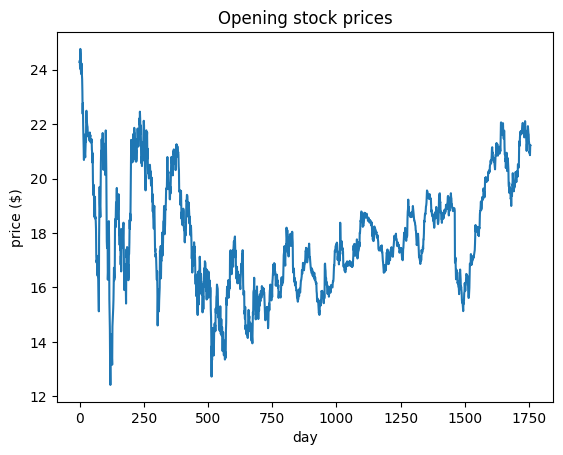

In [4]:
def plot_prices(prices):
    plt.title('Opening stock prices')
    plt.xlabel('day')
    plt.ylabel('price ($)')
    plt.plot(prices)
    plt.savefig('prices.png')

if __name__ == '__main__':
    prices = get_prices('MSFT', '2007-01-01', '2026-01-01', 'historical_stock_prices.npy')
    plot_prices(prices)

## 3. Definición del entorno y la política base

El **estado** es un vector de 202 dimensiones: `[presupuesto, num_acciones, últimos_200_precios]`

In [5]:
# Clase base: Política de decisión
class DecisionPolicy:

    def select_action(self, current_state, step):
        pass

    def update_q(self, state, action, reward, next_state):
        pass


# Política aleatoria
class RandomDecisionPolicy(DecisionPolicy):
    def __init__(self, actions):
        self.actions = actions

    def select_action(self, current_state, step):
        action = self.actions[random.randint(0, len(self.actions) - 1)]
        return action


## 4. Función de simulación

In [6]:
def run_simulation(policy, initial_budget, initial_num_stocks, prices, hist, debug=False):
    # Ejecuta una simulación de trading usando la política dada.
    budget = initial_budget
    num_stocks = initial_num_stocks
    share_value = 0
    transitions  = list()

    for i in range(len(prices) - hist - 1):
        if i % 100 == 0: 
            print('progress {:.2f}%'.format(float(100*i) /(len(prices) - hist - 1 )))
        
        current_state = np.asmatrix(
            np.hstack((prices[i:i + hist], budget, num_stocks))
        )

        current_portfolio = budget + num_stocks * share_value

        # Paso 1: seleccionar acción 
        action = policy.select_action(current_state, i)

        share_value = float(prices[i + hist + 1])

        # Paso 2: ejecutar acción
        if action == 'Buy' and budget >= share_value:
            budget -= share_value
            num_stocks += 1
            buy_points.append((i, share_value))
        elif action == 'Sell' and num_stocks > 0:
            budget += share_value
            num_stocks -= 1
        else:
            action = 'Hold'

        new_portfolio = budget + num_stocks * share_value

        reward = new_portfolio - current_portfolio

        next_state = np.asmatrix(
            np.hstack((prices[i + 1:i + hist + 1], budget, num_stocks))
        )

        # Paso 3: actualizar política
        transitions.append((current_state, action, reward, next_state))
        policy.update_q(current_state, action, reward, next_state)

    #valor final del portafolio
    portfolio = budget + num_stocks * share_value

    if debug:
        print(f"Presupuesto final : ${budget:.2f}")
        print(f"Acciones restantes: {num_stocks}")
        print(f"Portafolio final  : ${portfolio:.2f}")

    return portfolio

In [7]:
def run_simulations(policy, budget, num_stocks, prices, hist, num_tries=100):

    #Ejecuta múltiples simulaciones y devuelve el promedio y desviación estándar.

    final_portfolios = []
    for i in range(num_tries):
        portfolio, _, _ = run_simulation(policy, budget, num_stocks, prices, hist)
        final_portfolios.append(portfolio)

    avg = np.mean(final_portfolios)
    std = np.std(final_portfolios)
    return avg, std, final_portfolios


## 5. Evaluación de la Política Aleatoria

In [8]:
# ── Parámetros del entorno ────────────────────────────────────────────────────
actions = ['Buy', 'Sell', 'Hold']
hist = 200 #últimos 200 precios
budget = 1000.0 
num_stocks = 0